In [8]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve  

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from pathlib import Path

Number of features in X_train: 32
Best number of features according to RFECV: 32

Selected feature indices (RFECV best subset):
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]

Selected feature names:
['HISTO_NET_T1_Bin5', 'HISTO_NET_T1_Bin9', 'HISTO_ET_T2_Bin4', 'HISTO_ED_T2_Bin2', 'HISTO_ED_T2_Bin10', 'HISTO_NET_T2_Bin10', 'HISTO_ET_FLAIR_Bin5', 'HISTO_ED_FLAIR_Bin10', 'HISTO_NET_FLAIR_Bin1', 'SPATIAL_Temporal', 'SPATIAL_Insula', 'TEXTURE_GLOBAL_ET_T1Gd_Skewness', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLOBAL_ED_T1Gd_Kurtosis', 'TEXTURE_GLOBAL_ED_T1_Skewness', 'TEXTURE_GLOBAL_NET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_GLCM_ED_T1Gd_Correlation', 'TEXTURE_GLCM_NET_FLAIR_AutoCorrelation', 'TEXTURE_GLRLM_ED_T1Gd_LRLGE', 'TEXTURE_GLRLM_ED_T2_LGRE', 'TEXTURE_GLRLM_ED_T2_RLV', 'TEXTURE_GLRLM_NET_FLAIR_HGRE', 'TEXTURE_GLSZM_ET_T2_LZLGE', 'TEXTURE_GLSZM_ED_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1_

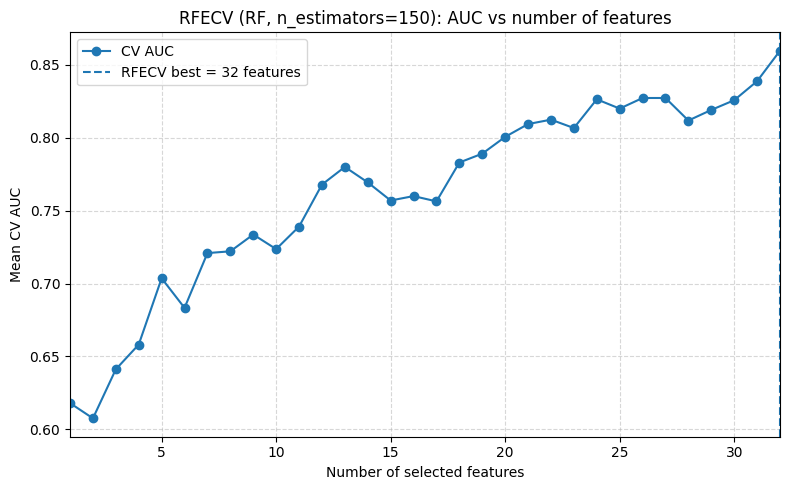

In [9]:

# =========================
# 0) Reproducibility settings
# =========================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# X_train, X_test, y_train, y_test are assumed to be already loaded.
# e.g.
DATA_DIR = Path("../data")

X_train = pd.read_csv("../nz/Xtr_nz.csv")
X_test  = pd.read_csv("../nz/Xte_nz.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

# =========================
# 1) RFECV setup
# =========================

def make_rf(seed: int = 42):
    """CPU-based RandomForest for RFECV (fixed hyperparameters)."""
    return RandomForestClassifier(
        n_estimators=150,     # fixed number of trees
        max_depth=12,         # maximum depth of each tree
        min_samples_leaf=2,   # minimum samples per leaf
        bootstrap=True,       # use bootstrap sampling
        n_jobs=-1,             # single core for determinism
        random_state=seed,    # random seed for reproducibility
    )

rf_for_rfe = make_rf(seed=RANDOM_STATE)

cv_sel = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rfecv = RFECV(
    estimator=rf_for_rfe,       # RF used inside RFECV
    step=1,                     # remove one feature at each step
    cv=cv_sel,
    scoring="roc_auc",
    n_jobs=-1,                   # single core for determinism
    min_features_to_select=1,   # go down to 1 feature to see full curve
)

# =========================
# 2) Fit RFECV on the training data
# =========================
rfecv.fit(X_train, y_train)

print("Number of features in X_train:", rfecv.n_features_in_)
print("Best number of features according to RFECV:", rfecv.n_features_)

# Boolean mask of selected features (best subset)
support_mask = rfecv.support_
selected_idx = np.where(support_mask)[0]

print("\nSelected feature indices (RFECV best subset):")
print(selected_idx)
print("\nSelected feature names:")
print(list(X_train.columns[selected_idx]))

# =========================
# 3) Extract CV results for plotting
# =========================
try:
    # Newer scikit-learn versions
    mean_scores = rfecv.cv_results_["mean_test_score"]
    n_features = rfecv.cv_results_["n_features"]
except AttributeError:
    # Older versions (grid_scores_)
    mean_scores = rfecv.grid_scores_
    n_total = rfecv.n_features_in_
    min_feat = rfecv.min_features_to_select
    step = rfecv.step
    n_features = np.arange(n_total, min_feat - 1, -step)[::-1]

# =========================
# 4) Plot AUC vs number of selected features
# =========================
plt.figure(figsize=(8, 5))
plt.plot(n_features, mean_scores, marker="o", label="CV AUC")

# Vertical line at RFECV's chosen number of features
plt.axvline(
    x=rfecv.n_features_,
    linestyle="--",
    label=f"RFECV best = {rfecv.n_features_} features"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV AUC")
plt.title("RFECV (RF, n_estimators=150): AUC vs number of features")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, X_train.shape[1])
plt.legend()
plt.tight_layout()
plt.show()


Best AUC among n_features <= 15: 0.7800 at k = 13


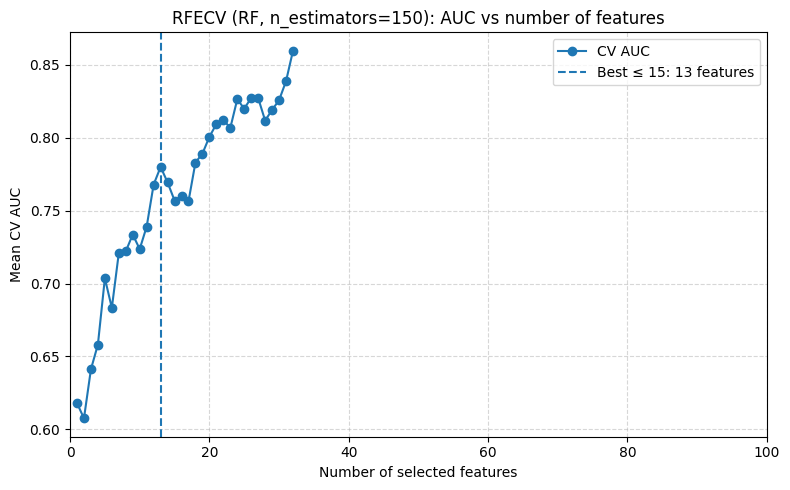

In [10]:
# =========================
# 4) Plot AUC vs number of selected features (0 ~ 100 only,
#    with vertical line at best k ≤ 20)
# =========================

# Find best AUC among n_features <= 15 (including 15)
mask_le15 = n_features <= 15
n_feat_le15 = n_features[mask_le15]
scores_le15 = mean_scores[mask_le15]

best_idx_le15 = np.argmax(scores_le15)
best_k_le15 = int(n_feat_le15[best_idx_le15])
best_auc_le15 = float(scores_le15[best_idx_le15])

print(f"Best AUC among n_features <= 15: {best_auc_le15:.4f} at k = {best_k_le15}")

plt.figure(figsize=(8, 5))
plt.plot(n_features, mean_scores, marker="o", label="CV AUC")

# Vertical line at best k among n_features <= 15
plt.axvline(
    x=best_k_le15,
    linestyle="--",
    label=f"Best ≤ 15: {best_k_le15} features"
)

plt.xlabel("Number of selected features")
plt.ylabel("Mean CV AUC")
plt.title("RFECV (RF, n_estimators=150): AUC vs number of features")
plt.grid(True, linestyle="--", alpha=0.5)

# x-axis: 0 ~ 100
plt.xlim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# ============================================
# RF hyperparameter search space (now tuning n_estimators)
# ============================================
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # use the same global setting if defined
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

# ============================================
# 1) RF tuning on the chosen feature subset (selected_idx)
# ============================================
def tune_rf_for_features(feature_idx, label):
    """
    Given a feature subset (column indices), run RandomizedSearchCV
    for RF tuning (including n_estimators).
    """
    # Subset the training data to the given feature indices
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    # Base RF model; let RandomizedSearchCV tune n_estimators etc.
    base_rf = RandomForestClassifier(
        random_state=2042,
        n_jobs=-1
    )

    # RandomizedSearchCV over the hyperparameters
    rs = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_train)

    best_params = dict(rs.best_params_)
    # Clean up keys that are not needed when creating the final RF
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"\n[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

label = "RF (chosen feature subset)"
best_params, cv_auc_best = tune_rf_for_features(selected_idx, label)

# ============================================
# 2) Refit RF on full TRAIN and evaluate TRAIN / TEST AUC
# ============================================
# Build reduced TRAIN / TEST matrices
Xtr_sub = X_train.iloc[:, selected_idx].to_numpy()
Xte_sub = X_test.iloc[:,  selected_idx].to_numpy()

rf_final = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params   # includes n_estimators, max_depth, etc.
)
rf_final.fit(Xtr_sub, y_train)

# Predicted probabilities for AUC
prob_tr = rf_final.predict_proba(Xtr_sub)[:, 1]
prob_te = rf_final.predict_proba(Xte_sub)[:, 1]

auc_tr = roc_auc_score(y_train, prob_tr)
auc_te = roc_auc_score(y_test,  prob_te)

print("\n========== FINAL RESULTS: RF with chosen subset ==========")
print(f"[FINAL] {label}: CV best AUC (from tuning) = {cv_auc_best:.4f}")
print(f"[FINAL] {label}: TRAIN AUC = {auc_tr:.4f}")
print(f"[FINAL] {label}: TEST  AUC = {auc_te:.4f}")
print("==========================================================")



[CV] RF (chosen feature subset) best AUC = 0.8733
[CV] RF (chosen feature subset) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 135}

========== FINAL RESULTS: RF with chosen subset ==========
[FINAL] RF (chosen feature subset): CV best AUC (from tuning) = 0.8733
[FINAL] RF (chosen feature subset): TRAIN AUC = 0.9993
[FINAL] RF (chosen feature subset): TEST  AUC = 0.7083


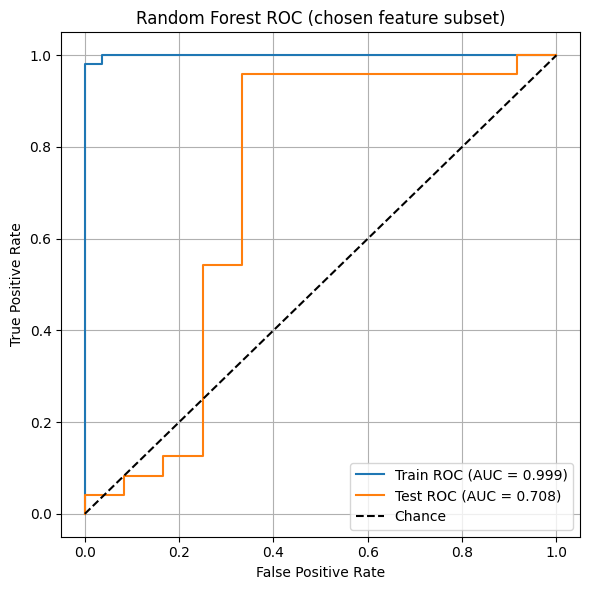

In [12]:
# ============================================
# 3) Plot ROC curves for TRAIN and TEST
# ============================================
fpr_tr, tpr_tr, _ = roc_curve(y_train, prob_tr)
fpr_te, tpr_te, _ = roc_curve(y_test,  prob_te)

plt.figure(figsize=(6, 6))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC = {auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC = {auc_te:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC (chosen feature subset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# =========================
# 0) Standardize features for SVM
# =========================
# We standardize X because SVM is sensitive to feature scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Build reduced TRAIN / TEST matrices using the same selected_idx (e.g., k=17)
Xtr_sub_svm = X_train_scaled[:, selected_idx]
Xte_sub_svm = X_test_scaled[:,  selected_idx]

print("Shapes for SVM (scaled, selected features):")
print("Xtr_sub_svm:", Xtr_sub_svm.shape)
print("Xte_sub_svm:", Xte_sub_svm.shape)

# ============================================
# 1) SVM hyperparameter search space (tune C)
# ============================================
PARAM_C = {
    "C": np.logspace(-3, 2, 20),   # from 0.001 to 100 on log scale
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # same global setting if defined
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_svm_for_features(X_sub, label):
    """
    Given a reduced feature matrix (already subset + scaled),
    run RandomizedSearchCV to tune C for a linear SVM.
    """
    base_svm = LinearSVC(
        penalty="l2",
        loss="squared_hinge",
        random_state=2042,
        max_iter=5000
    )

    rs = RandomizedSearchCV(
        estimator=base_svm,
        param_distributions=PARAM_C,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",     # uses decision_function under the hood
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_train)

    best_params = dict(rs.best_params_)

    print(f"\n[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

label_svm = "Linear SVM (same selected features as RF, e.g. k=17)"
best_params_svm, cv_auc_best_svm = tune_svm_for_features(Xtr_sub_svm, label_svm)

# ============================================
# 2) Refit SVM on full TRAIN and evaluate TRAIN / TEST AUC
# ============================================
svm_final = LinearSVC(
    penalty="l2",
    loss="squared_hinge",
    random_state=RANDOM_STATE,
    max_iter=5000,
    **best_params_svm
)
svm_final.fit(Xtr_sub_svm, y_train)

# Use decision_function for AUC (scores, not probabilities)
dec_tr = svm_final.decision_function(Xtr_sub_svm)
dec_te = svm_final.decision_function(Xte_sub_svm)

auc_tr_svm = roc_auc_score(y_train, dec_tr)
auc_te_svm = roc_auc_score(y_test,  dec_te)

print("\n========== FINAL RESULTS: Linear SVM with chosen subset ==========")
print(f"[FINAL] {label_svm}: CV best AUC (from tuning) = {cv_auc_best_svm:.4f}")
print(f"[FINAL] {label_svm}: TRAIN AUC = {auc_tr_svm:.4f}")
print(f"[FINAL] {label_svm}: TEST  AUC = {auc_te_svm:.4f}")
print("==================================================================")


Shapes for SVM (scaled, selected features):
Xtr_sub_svm: (82, 32)
Xte_sub_svm: (36, 32)

[CV] Linear SVM (same selected features as RF, e.g. k=17) best AUC = 0.9848
[CV] Linear SVM (same selected features as RF, e.g. k=17) best params = {'C': np.float64(0.06951927961775606)}

========== FINAL RESULTS: Linear SVM with chosen subset ==========
[FINAL] Linear SVM (same selected features as RF, e.g. k=17): CV best AUC (from tuning) = 0.9848
[FINAL] Linear SVM (same selected features as RF, e.g. k=17): TRAIN AUC = 1.0000
[FINAL] Linear SVM (same selected features as RF, e.g. k=17): TEST  AUC = 0.6146


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=80. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


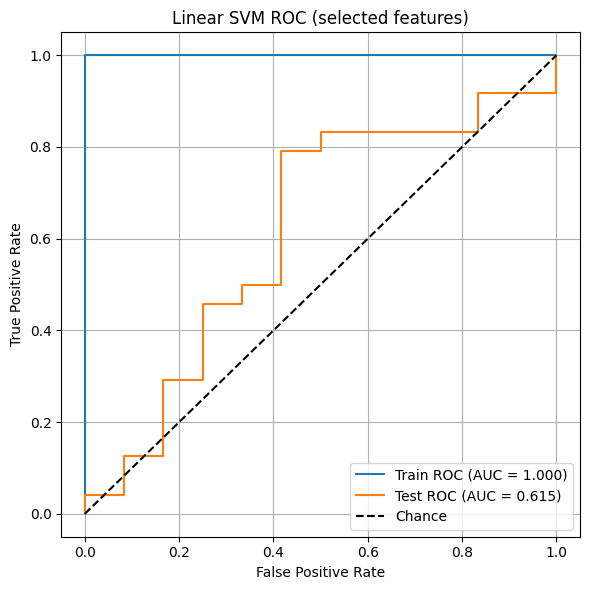

In [14]:
# ============================================
# 3) Plot ROC curves for TRAIN and TEST
# ============================================
fpr_tr_svm, tpr_tr_svm, _ = roc_curve(y_train, dec_tr)
fpr_te_svm, tpr_te_svm, _ = roc_curve(y_test,  dec_te)

plt.figure(figsize=(6, 6))
plt.plot(fpr_tr_svm, tpr_tr_svm, label=f"Train ROC (AUC = {auc_tr_svm:.3f})")
plt.plot(fpr_te_svm, tpr_te_svm, label=f"Test ROC (AUC = {auc_te_svm:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear SVM ROC (selected features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()